In [1]:
# !cp /vol/projects/CIIM/Healthy_Single_Cell_Data/count_matrix	 
!ls /vol/projects/aehsani/ImmuneAgeing/Immuneageing_v2/data/datasets/

data1.h5ad		   data4.rds		      data7.h5Seurat
data1.h5Seurat		   data5.h5ad		      data7_normalized.h5ad
data2.h5ad		   data5.h5Seurat	      data7_normalized.h5Seurat
data2.h5Seurat		   data5_normalized.h5ad      data7.rds
data2.rds		   data5_normalized.h5Seurat  data8.h5ad
data3.h5ad		   data5.rds		      data8.h5Seurat
data3.h5Seurat		   data6.h5ad		      data8_normalized.h5ad
data3.rds		   data6.h5Seurat	      data8_normalized.h5Seurat
data4.h5ad		   data6_normalized.h5ad      data8.rds
data4.h5Seurat		   data6_normalized.h5Seurat  meta_var_obs
data4_normalized.h5ad	   data6.rds
data4_normalized.h5Seurat  data7.h5ad


## Inport cell typist

In [66]:
from celltypist import models
import celltypist
models.download_models(
    force_update=True, model=["Immune_All_Low.pkl", "Immune_All_High.pkl"]
)
model_low = models.Model.load(model="Immune_All_Low.pkl")
model_high = models.Model.load(model="Immune_All_High.pkl")

def cell_typist(adata, model, meta='', layer='counts'):
    """Uses cell typist for annotation. Pass the raw count."""
    adata_celltypist = adata.copy()
    adata_celltypist.X = adata_celltypist.layers[layer]

    try:
        del adata_celltypist.obsp
    except:
        pass 
    try:
        del adata_celltypist.uns
    except:
        pass
    try:
        del adata_celltypist.varm
    except:
        pass 
    
    sc.pp.normalize_per_cell(
        adata_celltypist, counts_per_cell_after=10**4
    ) 
    sc.pp.log1p(adata_celltypist) 
    adata_celltypist.X = adata_celltypist.X.toarray()
    
    predictions = celltypist.annotate(
        adata_celltypist, model=model, majority_voting=True
    )
    
    predictions_adata = predictions.to_adata()

    adata.obs[f'cell_type_celltypist'] = predictions_adata.obs.majority_voting
    adata.obs[f'conf_score_celltypist'] = predictions_adata.obs.conf_score

📜 Retrieving model list from server https://celltypist.cog.sanger.ac.uk/models/models.json
📚 Total models in list: 52
📂 Storing models in /home/jnourisa/.celltypist/data/models
💾 Total models to download: 2
💾 Downloading model [1/2]: Immune_All_Low.pkl
💾 Downloading model [2/2]: Immune_All_High.pkl


# QC

In [4]:
import anndata as ad 
raw_dir = '../input/raw'
# for i in range(1, 2):
#     adata = ad.read_h5ad(f'{raw_dir}/data{i}_CMtx.h5ad')
sc_counts = ad.read_h5ad(f'{raw_dir}/data{2}_CMtx.h5ad')

In [5]:
import sctk
# sctk.calculate_qc(sc_counts, flags={"mito": r"^MT-", "ribo": r"^RP[LS]"})
sctk.calculate_qc(sc_counts)
sctk.cellwise_qc(sc_counts)

/home/jnourisa/miniconda3/envs/py10/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


n_counts: [1473.5994213120675, 3864.14013671875], 92607/95616 passed
n_genes: [710.6550642615703, 5926.998046875], 93467/95616 passed
percent_mito: [0.0, 3.4134281939768347], 94956/95616 passed
percent_ribo: [7.391714615774978, 17.80101009452192], 89452/95616 passed
percent_hb: [0.0, 0.002505168463850622], 61338/95616 passed
55832/95616 pass


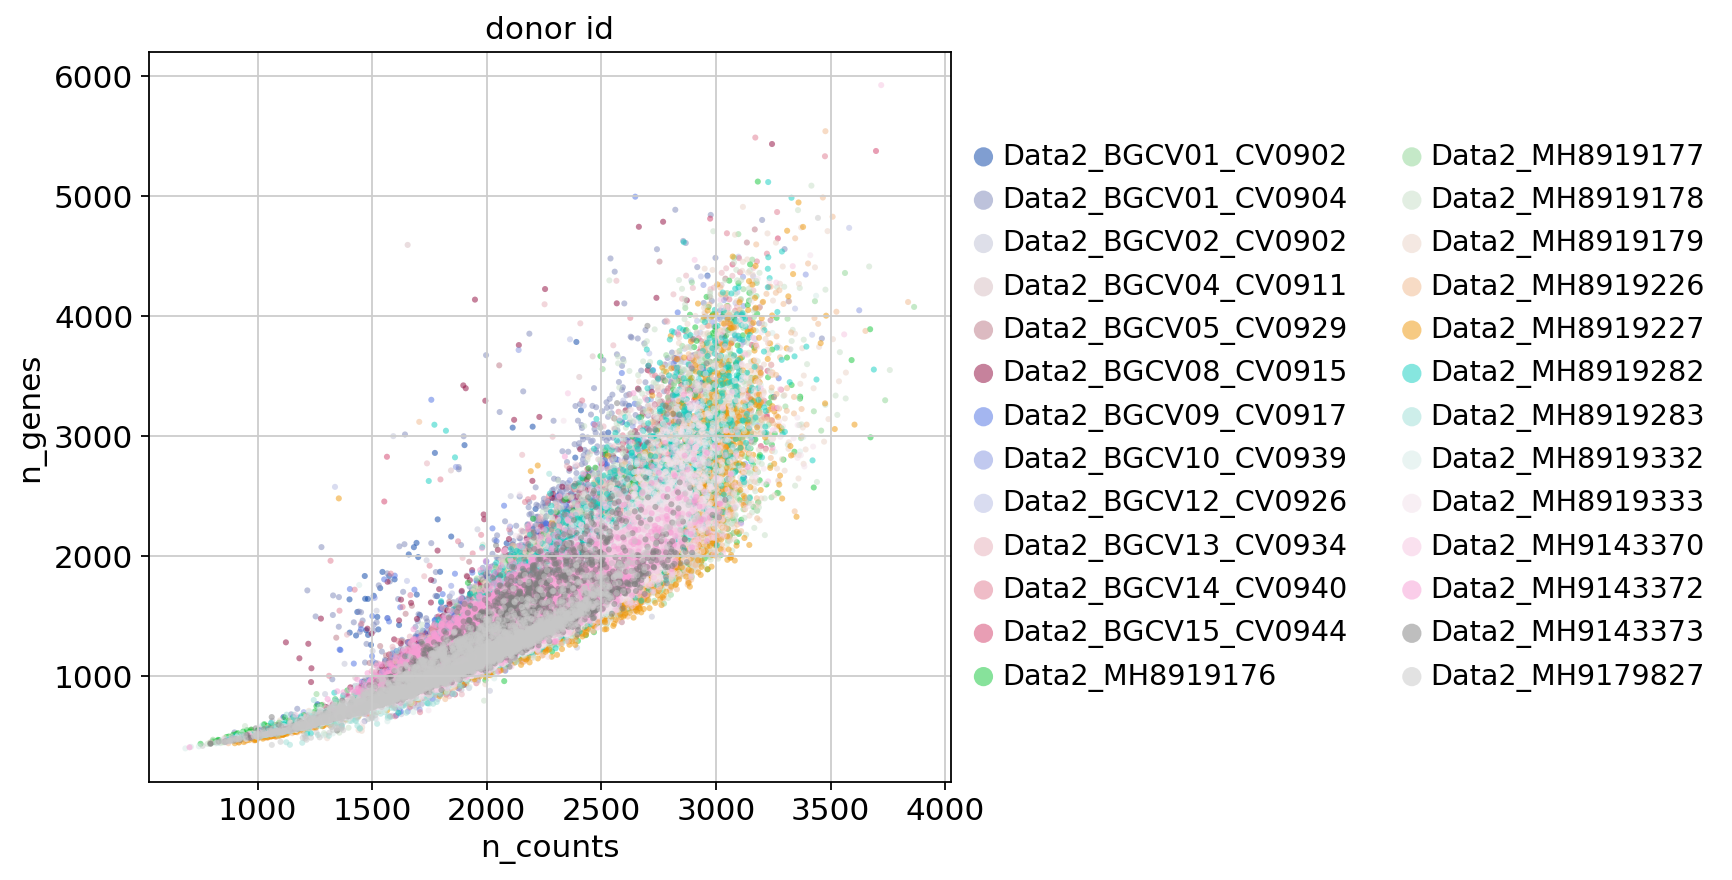

In [15]:
import scanpy as sc
sc.set_figure_params(figsize=(6,6))
p3 = sc.pl.scatter(sc_counts, "n_counts", "n_genes", color="donor_id", size=30, alpha=.5)

In [17]:
sctk.default_metric_params_df
def min_max(name, data):
    print(f'{name}: min:{data.min()}, max: {data.max()}')
min_max('n_counts', sc_counts.obs.n_counts)
min_max('n_genes', sc_counts.obs.n_genes)
min_max('percent_hb', sc_counts.obs.percent_hb)
min_max('percent_mito', sc_counts.obs.percent_mito)

n_counts: min:684.4703803178854, max: 3864.140673676622
n_genes: min:398, max: 5927
percent_hb: min:0.0, max: 2.485166602975038
percent_mito: min:0.0, max: 5.989891775130088


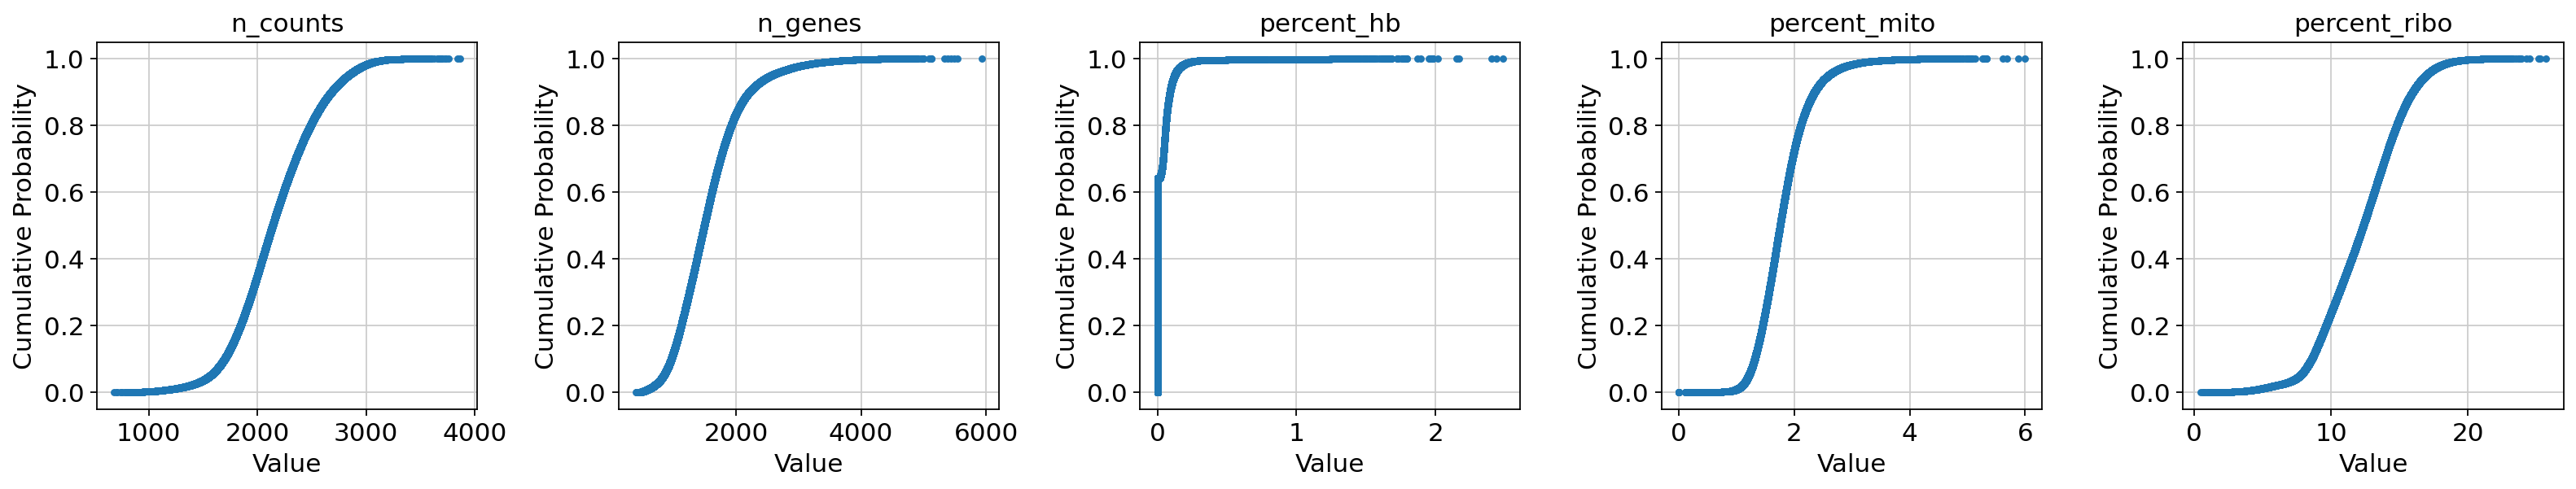

In [20]:
import matplotlib.pyplot as plt
import numpy as np
fig, axes = plt.subplots(1, 5, figsize=(20,4))
def plot_CDF(data, title, ax):
    x = np.sort(data)
    y = np.arange(1, len(data) + 1) / len(data)
    ax.plot(x, y, marker='.', linestyle='none')
    ax.set_xlabel('Value')
    ax.set_ylabel('Cumulative Probability')
    ax.set_title(title)
    ax.grid(True)

plot_CDF(sc_counts.obs.n_counts, 'n_counts', axes[0])
plot_CDF(sc_counts.obs.n_genes, 'n_genes', axes[1])
plot_CDF(sc_counts.obs.percent_hb, 'percent_hb', axes[2])
plot_CDF(sc_counts.obs.percent_mito, 'percent_mito', axes[3])
plot_CDF(sc_counts.obs.percent_ribo, 'percent_ribo', axes[4])
plt.tight_layout()
plt.show()

In [21]:
# for cells
print('n_counts:', sc_counts.obs.n_counts.min(), sc_counts.obs.n_counts.max())
print('n_genes:', sc_counts.obs.n_genes.min(), sc_counts.obs.n_genes.max())
print('percent_mito:', sc_counts.obs.percent_mito.min(), sc_counts.obs.percent_mito.max())
print('percent_ribo:', sc_counts.obs.percent_ribo.min(), sc_counts.obs.percent_ribo.max())
print('percent_hb:', sc_counts.obs.percent_hb.min(), sc_counts.obs.percent_hb.max())

n_counts: 684.4703803178854 3864.140673676622
n_genes: 398 5927
percent_mito: 0.0 5.989891775130088
percent_ribo: 0.44452174888665386 25.69922981093716
percent_hb: 0.0 2.485166602975038


In [4]:
def remove_low_q_genes(sc_counts, group='plate_name', threshold=100):
    import numpy as np
    import pandas as pd

    plates = sc_counts.obs[group].unique()
    gene_counts_per_plate = pd.DataFrame(index=sc_counts.var_names, columns=plates, dtype=int)

    for plate in plates:
        # Subset the AnnData object for the current plate
        subset = sc_counts[sc_counts.obs[group] == plate]
        
        # Calculate expression counts (genes x cells > 0)
        expressed_genes = (subset.X > 0).sum(axis=0)
        
        # Check if the result needs conversion from sparse matrix format
        if isinstance(expressed_genes, np.matrix):
            expressed_genes = np.array(expressed_genes).flatten()
        
        # Store the counts in the DataFrame
        gene_counts_per_plate[plate] = expressed_genes

    max_counts = gene_counts_per_plate.max(axis=1)
    genes_to_keep = max_counts >= threshold


AnnData object with n_obs × n_vars = 1248980 × 24281
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'donor_id', 'age', 'sex', 'batch_info', 'ct_major_published'
    var: 'features'

In [26]:
sc_counts

AnnData object with n_obs × n_vars = 95616 × 24304
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'donor_id', 'age', 'sex', 'batch_info', 'ct_major_published', 'n_counts', 'log1p_n_counts', 'n_genes', 'log1p_n_genes', 'percent_mito', 'n_counts_mito', 'percent_ribo', 'n_counts_ribo', 'percent_hb', 'n_counts_hb', 'percent_top50', 'cell_passed_qc'
    var: 'features', 'mito', 'ribo', 'hb', 'n_counts', 'n_cells'
    uns: 'scautoqc_ranges', 'donor_id_colors'

In [ ]:
def func_leiden(adata):
    adata.layers['counts'] = adata.X.copy()
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    sc.pp.highly_variable_genes(adata, n_top_genes=2000)
    sc.tl.pca(adata, n_comps=50, use_highly_variable=True)
    sc.pp.neighbors(adata, n_pcs=30)
    sc.tl.umap(adata)
    sc.tl.leiden(adata)

def plot_umap(adata_o, color='leiden', ax=None, groups=None, color_map=None, s=1, mask_group=None, legend_loc=None):
    adata = adata_o.copy()
    if groups is not None:
        adata.obs[color] = adata.obs[color].astype(str)
        mask = adata.obs[color].isin(groups)
        print(mask.sum())
        adata.obs.loc[~mask, color] = 'background'
        #     adata.obs['color'] = adata.obs['color'].astype(str).astype(categorical)
    if mask_group is not None:
        adata.obs[color] = adata.obs[color].astype(str)
        adata.obs.loc[~mask_group, color] = 'background'
        
    x_data = adata.obsm['X_umap'][:,0]
    y_data = adata.obsm['X_umap'][:,1]
    xlim = [min(x_data)+.1*min(x_data), max(x_data)+.1*max(x_data)]
    ylim = [min(y_data)+.1*min(y_data), max(y_data)+.1*max(y_data)]
    if isinstance(adata.obs[color].iloc[0], (int, float)):
        # Continuous variable
        scatter = ax.scatter(x_data, y_data, c=adata.obs[color], cmap='viridis', alpha=0.3, s=1)
        plt.colorbar(scatter, ax=ax)
    else:
        unique_colors = sorted(adata.obs[color].unique())  # Sort unique colors alphabetically

        num_colors = len(unique_colors)
        if num_colors > 10:
            cmap = plt.get_cmap('tab20')  # Use a color map with more distinct colors
            color_list = cmap(np.linspace(0, 1, num_colors))
            color_list = [list(color_list[i]) for i in range(num_colors)]  # Convert each color to list format

        else:
            color_list = None  # Use default color map if fewer than 10 colors
            
        for i, c in enumerate(unique_colors):
            mask = adata.obs[color]==c
            if c == 'background':
                ax.scatter(x_data[mask], y_data[mask], s=.5, label=c, color='lightgrey', alpha=.01)
            else:
                if color_map is None:
                    color_i = color_list[i] if color_list else None
                else:
                    try:
                        color_i = color_map[c]
                    except:
                        color_i = color_list[i] if color_list else None
                        # print('group was not found in color map. Using default color')
                ax.scatter(x_data[mask], y_data[mask], s=s, label=c, color=color_i , alpha=.3)
            if color == 'leiden':
                avg_x = np.mean(x_data[mask])
                avg_y = np.mean(y_data[mask])
                ax.annotate(c, (avg_x, avg_y),ha='center', fontsize=15)

    ax.set_xlabel('UMAP1')
    ax.set_ylabel('UMAP2')
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_xticks([])
    ax.set_yticks([])

    if color!='leiden':
        if legend_loc is None:
            legend = ax.legend(loc='upper left', bbox_to_anchor=(1,1), frameon=False)
        else:
            legend = ax.legend(loc=legend_loc)
        # legend = ax.legend()
        for handle in legend.legendHandles:
            handle.set_sizes([50])
            handle.set_alpha(1.0)  # Set legend handle alpha to 1.0 for full visibility

    ax.set_title(color)
    
def plot_umap_group(adata, colors, **kywds):
    n = len(colors)
    fig, axes = plt.subplots(1, n, figsize=(6*n, 4))
    for ii, color in enumerate(colors):
        plot_umap(adata, color=color, ax=axes[ii], **kywds)
    plt.tight_layout()
    return fig
def plot_umap_group_group(adatas, colors, mask_groups=None, **kywds):
    m = len(adatas)
    n = len(colors)
    fig, axes = plt.subplots(m, n, figsize=(7*n, 5*m))
    for ii, adata in enumerate(adatas):
        for jj, color in enumerate(colors):
            if mask_groups is not None:
                mask = mask_groups[ii]
            else:
                mask = None
            plot_umap(adata, color=color, ax=axes[ii][jj], mask_group=mask, **kywds)
    plt.tight_layout()
    return fig   

In [28]:
# run cell tyle annotation per donar

    

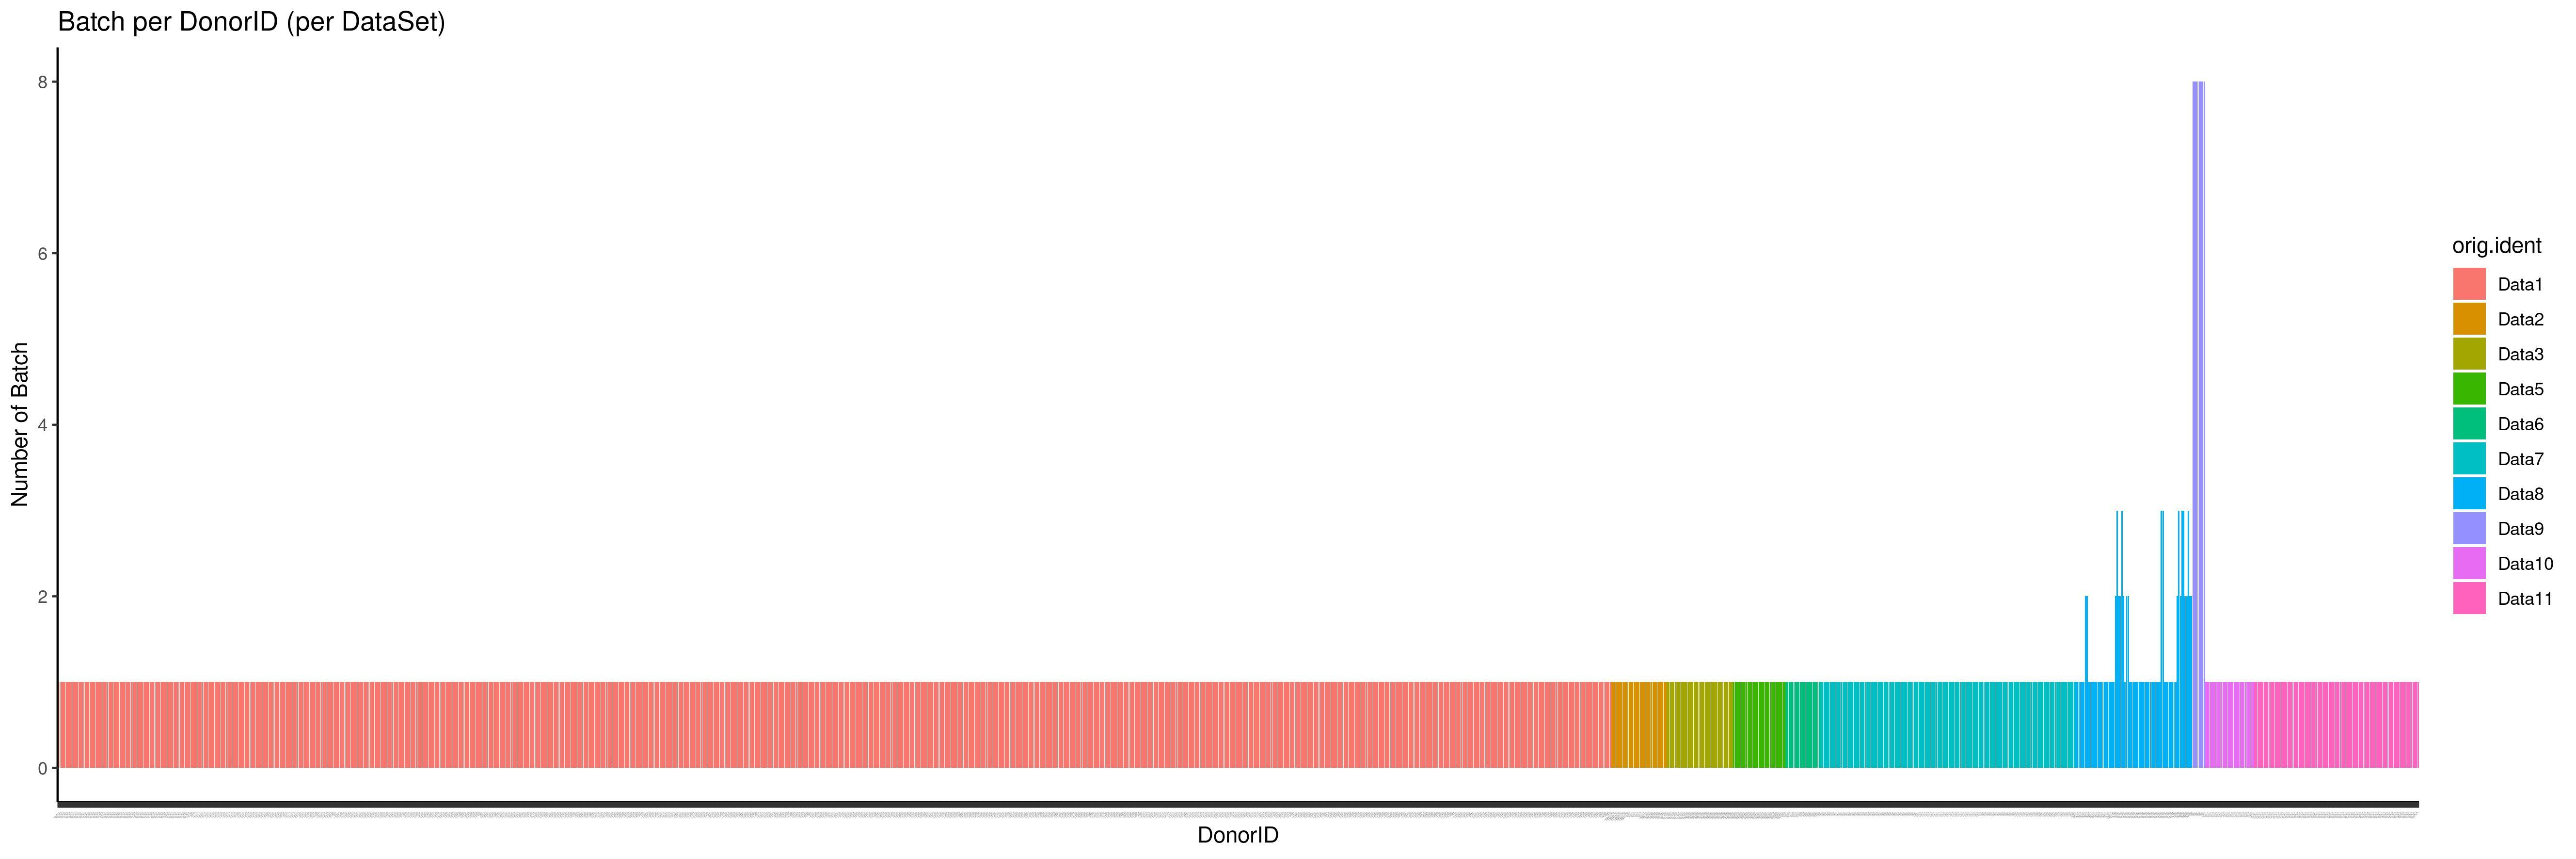


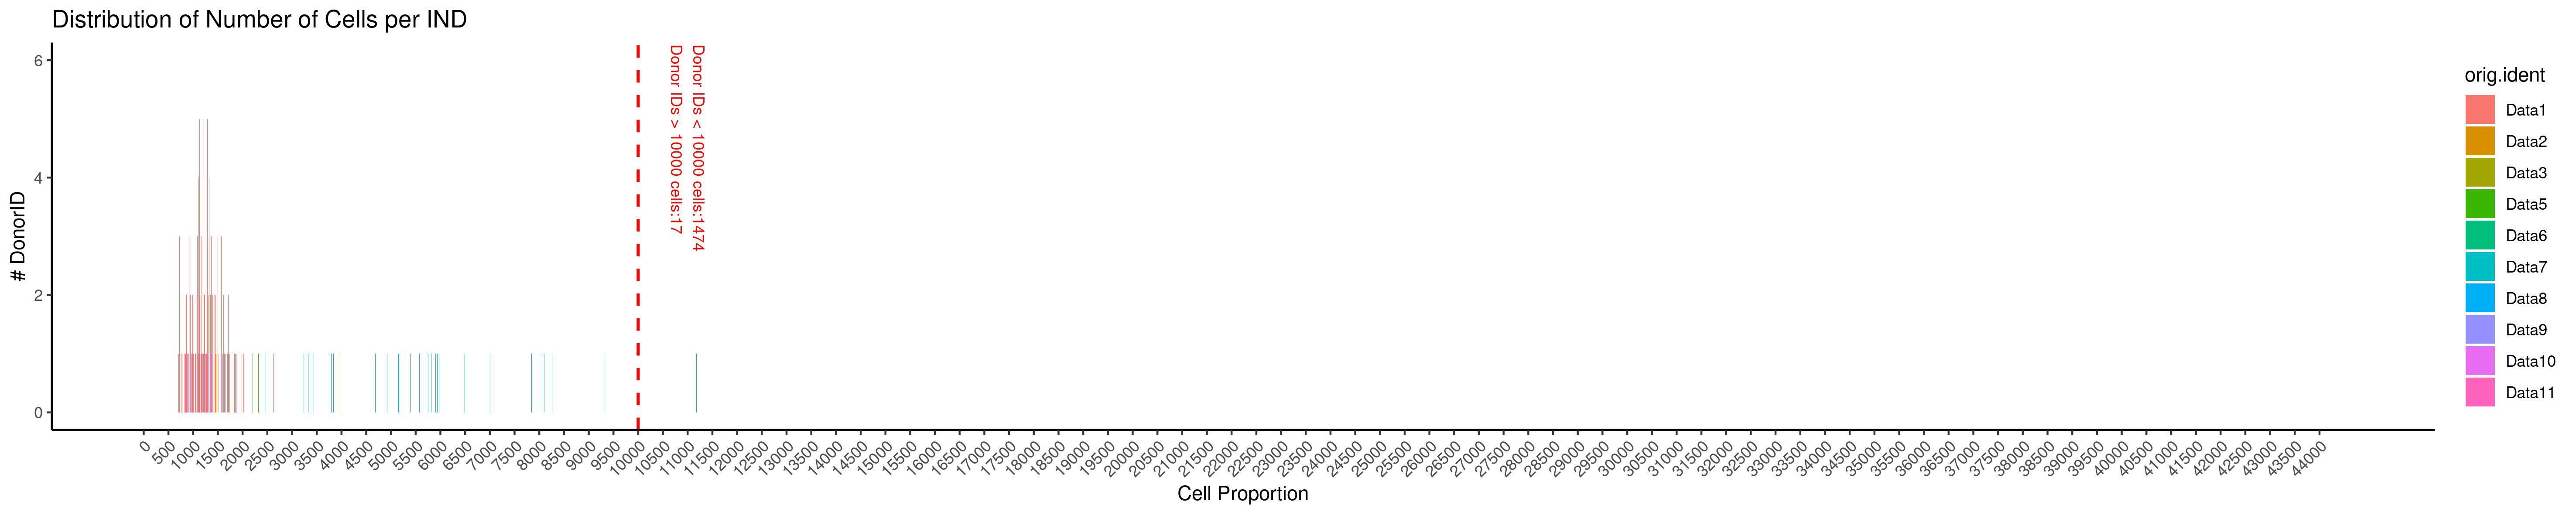

# scGPT

### Download pretrained models

In [50]:
url = "https://drive.google.com/drive/folders/1HsPrwYGPXm867_u_Ye0W4Ch8AFSneXAn"

# Download the folder
gdown.download_folder(url, quiet=True, use_cookies=False)

['/home/jnourisa/projs/ongoing/ciim/notebooks/finetuned_scGPT_adamson/args.json',
 '/home/jnourisa/projs/ongoing/ciim/notebooks/finetuned_scGPT_adamson/best_model.pt',
 '/home/jnourisa/projs/ongoing/ciim/notebooks/finetuned_scGPT_adamson/vocab.json']

In [54]:
!mv finetuned_scGPT_adamson ../input/scgpt/

rm: cannot remove '../input/scgpt/finetuned_scGPT_adamson': Is a directory


### Prepare sample data

In [107]:
test_data = sc_counts[sc_counts.obs['donor_id']=='Data2_BGCV01_CV0904'][:, :5000]
test_data.layers['counts'] = test_data.X.copy()
cell_typist(test_data, model_low, meta='', layer='counts')

🔬 Input data has 6853 cells and 5000 genes
🔗 Matching reference genes in the model
🧬 1252 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Can not detect a neighborhood graph, will construct one before the over-clustering
⛓️ Over-clustering input data with resolution set to 10
🗳️ Majority voting the predictions
✅ Majority voting done!


In [108]:
# !mkdir ../output/processed_data
test_data.obs['cell_type'] = test_data.obs.cell_type_celltypist

test_data.obs = test_data.obs[['cell_type']]
del test_data.uns

In [109]:
test_data.var = test_data.var[[]]

In [111]:
del test_data.raw

In [112]:
test_data.write_h5ad('../output/processed_data/test_adata.h5ad')